# CAT12 QC review

Exploratory only — no outputs committed (nbstripout). Reads the shared
brainlink.db via bagpipe's config, no paths/data hardcoded here.

Reviews the QC profile CAT12 reports per session (SIQR, NCR/ICR,
resolution, contrast, WMH burden, CAT version — `bagpipe.app.cat12_parse.
parse_quality`, `cat12_quality` table) across two sources:

- `cat12` — the training-era CAT12.9/2577 export ingested from
  `paths.cat12_images_dir` (`bag ingest cat12`).
- `cat12_v26` — the ongoing CAT26.0.rc3 reprocessing cohort
  (`config/cat12_cohort.yaml: output_derivatives_dir`, `bag ingest
  cat12-cohort`). A different CAT version than training — see CLAUDE.md's
  Phase 4 status notes — so this is also the first direct look at whether
  reprocessing shifts QC/region volumes.

Feature rows from both sources also coexist in `features`
(`source="cat12"` vs `"cat12_v26"`), so region-volume drift is checkable
too, not just QC scores.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bagpipe.db.base import get_session
from bagpipe.db.models import Cat12Quality, Feature

sns.set_theme(style="whitegrid")


## 1. Load QC profiles

In [2]:
with get_session() as s:
    quality = pd.read_sql(s.query(Cat12Quality).statement, s.bind)

print(quality.groupby("source").size())
quality.head()


source
cat12        5748
cat12_v26    2624
dtype: int64


,id,subject_key,session_id,source,siqr_pct,siqr_grade,ncr,icr,res_rms_mm,contrast,gmv_tiv_pct,vol_abs_wmh,vol_rel_wmh,cat_version,cat_revision,ingested_at
0,1,200109071247,200109071247,cat12_v26,79.86,C+,0.039923,0.133966,1.385378,28.719559,37.636,3.527795,0.002276,26.0.rc3,2874,2026-08-23 06:06:59
1,2,200112071234,200112071234,cat12_v26,76.68,C+,0.053023,0.171928,1.385378,27.167679,29.714,3.195848,0.002273,26.0.rc3,2874,2026-08-23 06:06:59
2,3,200201181249,200201181249,cat12_v26,80.28,B-,0.046533,0.101367,1.155828,31.756149,33.949,4.523861,0.003407,26.0.rc3,2874,2026-08-23 06:06:59
3,4,200207171551,200207171551,cat12_v26,76.79,C+,0.054555,0.138304,1.155828,25.072723,32.389,9.952821,0.006569,26.0.rc3,2874,2026-08-23 06:06:59
4,5,200207311554,200207311554,cat12_v26,79.78,C+,0.044027,0.176056,1.385378,30.137543,33.957,1.695879,0.001441,26.0.rc3,2874,2026-08-23 06:06:59


## 2. SIQR — headline quality score

`qc_gate`'s threshold (`DEFAULT_IQR_THRESHOLD = 70.0`, `bagpipe.app.
pipeline.qc`) is drawn as a reference line — sessions left of it would fail
the Pillar-4 upload gate were they run through it.


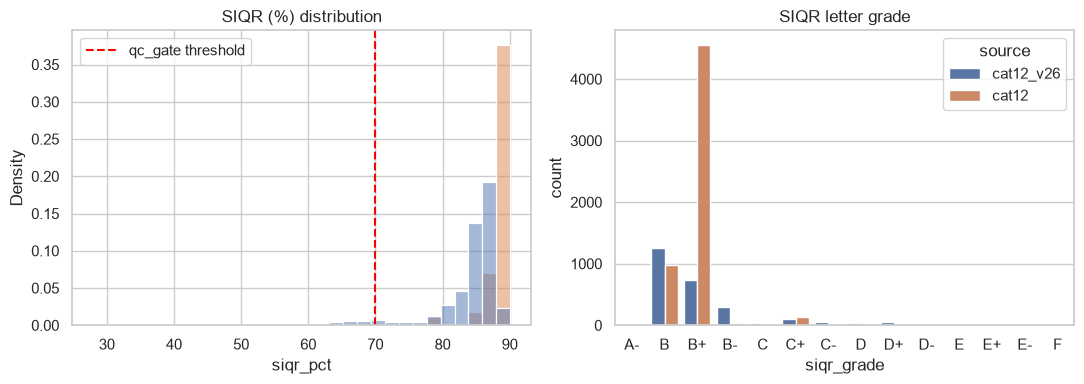

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=quality, x="siqr_pct", hue="source", bins=30, ax=axes[0], stat="density", common_norm=False)
axes[0].axvline(70.0, color="red", linestyle="--", label="qc_gate threshold")
axes[0].set_title("SIQR (%) distribution")
axes[0].legend()

grade_order = sorted(quality["siqr_grade"].dropna().unique())
sns.countplot(data=quality, x="siqr_grade", hue="source", order=grade_order, ax=axes[1])
axes[1].set_title("SIQR letter grade")

plt.tight_layout()


In [4]:
quality.sort_values("siqr_pct")

,id,subject_key,session_id,source,siqr_pct,siqr_grade,ncr,icr,res_rms_mm,contrast,gmv_tiv_pct,vol_abs_wmh,vol_rel_wmh,cat_version,cat_revision,ingested_at
5946,5947,200602051019,200602051019,cat12_v26,27.97,F,0.413326,3.360498,1.385349,54.208618,61.746,7.988361,0.007106,26.0.rc3,2874,2026-08-23 17:32:36
5803,5804,200512180842,200512180842,cat12_v26,29.06,F,0.147456,1.704752,1.437527,4.969337,62.852,0.000000,0.000000,26.0.rc3,2874,2026-08-23 11:14:52
5936,5937,200601101232,200601101232,cat12_v26,29.54,F,1.114782,6.776973,1.421361,24.006958,60.326,26.604458,0.023556,26.0.rc3,2874,2026-08-23 13:37:17
5911,5912,200702181105,200702181105,cat12_v26,29.88,F,1.013747,8.992324,1.075627,16.355347,53.602,14.569477,0.008873,26.0.rc3,2874,2026-08-23 11:14:52
5874,5875,200612190905,200612190905,cat12_v26,29.93,F,17.038033,169.111252,1.075615,0.967285,53.477,13.497069,0.008320,26.0.rc3,2874,2026-08-23 11:14:52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,223,200702020214,200702020214,cat12,NaN,None,NaN,NaN,1.385430,NaN,NaN,NaN,NaN,12.9,2577,2026-08-23 06:13:28
1141,1142,S000676,202406171852,cat12,NaN,None,NaN,NaN,0.901563,NaN,NaN,NaN,NaN,12.9,2577,2026-08-23 06:13:29
2641,2642,S302010,202006161003,cat12,NaN,None,NaN,NaN,0.898959,NaN,NaN,NaN,NaN,12.9,2577,2026-08-23 06:13:29
4463,4464,S689810,201905220849,cat12,NaN,None,0.054608,0.323777,0.901564,163.624496,NaN,2.060511,0.001263,12.9,2577,2026-08-23 06:13:29


In [6]:
threshold = 70.0
pass_rate = (
    quality.assign(passes=lambda d: d["siqr_pct"] >= threshold)
    .groupby("source")["passes"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pass_rate", "count": "n_sessions"})
)
pass_rate


,pass_rate,n_sessions
source,,
cat12,0.997216,5748
cat12_v26,0.942835,2624


## 3. Noise / contrast / resolution submetrics

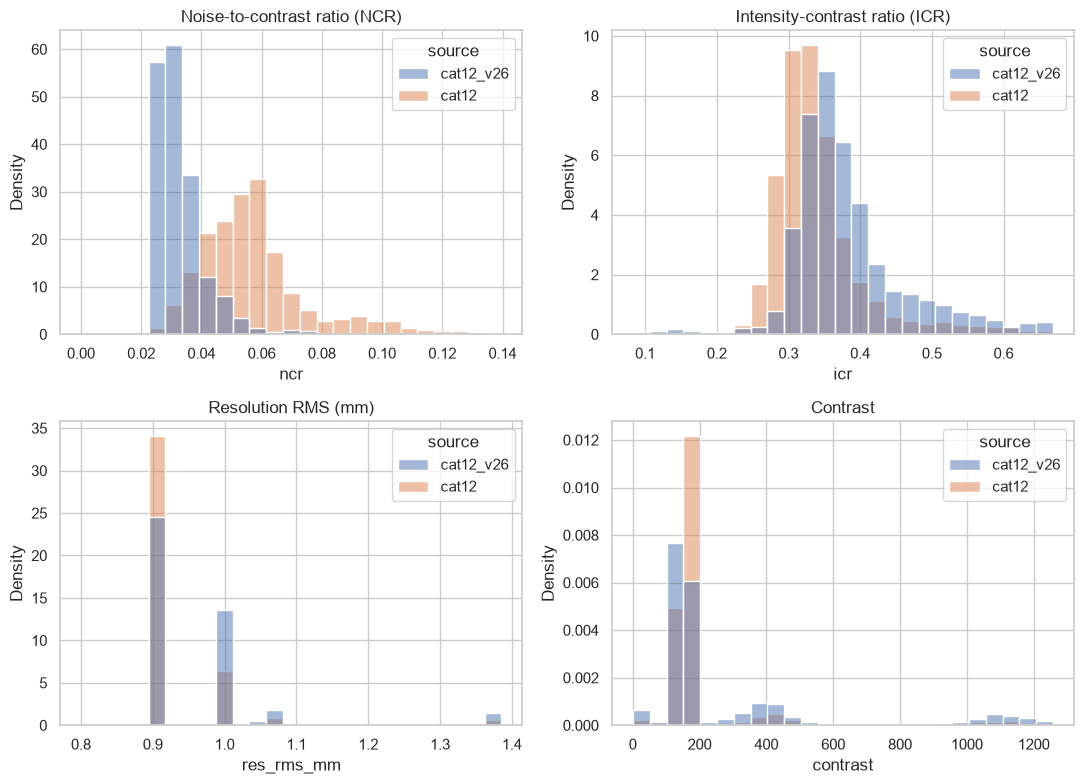

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col, title in zip(
    axes.flat,
    ["ncr", "icr", "res_rms_mm", "contrast"],
    ["Noise-to-contrast ratio (NCR)", "Intensity-contrast ratio (ICR)",
     "Resolution RMS (mm)", "Contrast"],
):
    # make a copy of the quality dataframe and remove outliers for better visualization
    quality_no_outliers = quality.copy()
    quality_no_outliers = quality_no_outliers[quality_no_outliers[col] < quality_no_outliers[col].quantile(0.99)]
    sns.histplot(data=quality_no_outliers, x=col, hue="source", bins=25, ax=ax, stat="density", common_norm=False)
    ax.set_title(title)
plt.tight_layout()


In [8]:
quality[quality["subject_key"] == "200707270944"]

,id,subject_key,session_id,source,siqr_pct,siqr_grade,ncr,icr,res_rms_mm,contrast,gmv_tiv_pct,vol_abs_wmh,vol_rel_wmh,cat_version,cat_revision,ingested_at
5996,5997,200707270944,200707270944,cat12_v26,65.71,D,0.04304,0.325253,1.38539,367.00354,31.229,4.450631,0.005157,26.0.rc3,2874,2026-08-24 05:18:23


In [13]:
quality[quality["subject_key"] == "200110171735"]

,id,subject_key,session_id,source,siqr_pct,siqr_grade,ncr,icr,res_rms_mm,contrast,gmv_tiv_pct,vol_abs_wmh,vol_rel_wmh,cat_version,cat_revision,ingested_at
41,42,200110171735,200110171735,cat12,79.57,C+,0.082462,0.127667,1.385378,35.588165,NaN,11.159335,0.009464,12.9,2577,2026-08-23 06:13:28
6228,6229,200110171735,200110171735,cat12_v26,75.69,C,0.055688,0.138079,1.385378,25.095505,32.06,9.900386,0.008462,26.0.rc3,2874,2026-08-24 20:46:30


## 4. WMH burden and TIV-normalized GM

`vol_rel_wmh` / `gmv_tiv_pct` come straight off `cat12_quality`; `TIV` is
`vol_TIV` in `subjectmeasures`, already in the QC-derived globals via
`parse_globals` at ingest time — join it in here for a TIV-vs-quality look.


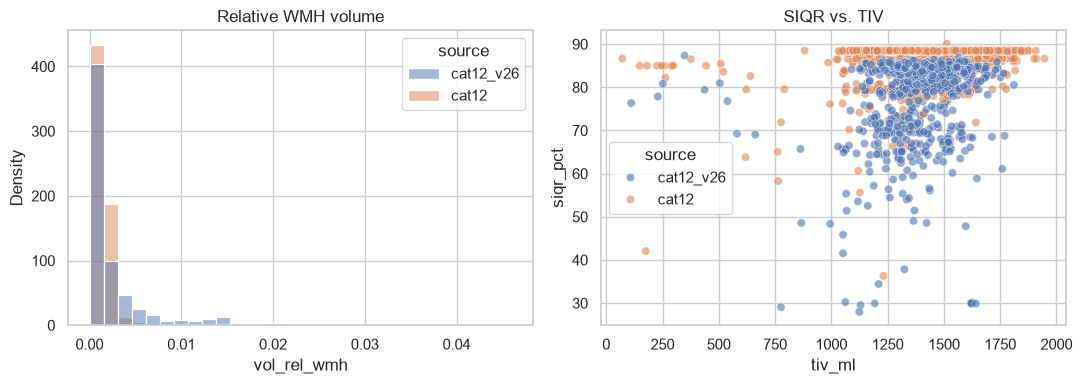

In [8]:
with get_session() as s:
    tiv = pd.read_sql(
        s.query(Feature)
        .filter(Feature.region == "global", Feature.metric == "TIV")
        .statement,
        s.bind,
    )[["subject_key", "session_id", "source", "value"]].rename(columns={"value": "tiv_ml"})

qc_tiv = quality.merge(tiv, on=["subject_key", "session_id", "source"], how="left")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=quality, x="vol_rel_wmh", hue="source", bins=30, ax=axes[0], stat="density", common_norm=False)
axes[0].set_title("Relative WMH volume")
sns.scatterplot(data=qc_tiv, x="tiv_ml", y="siqr_pct", hue="source", alpha=0.6, ax=axes[1])
axes[1].set_title("SIQR vs. TIV")
plt.tight_layout()


## 5. CAT12.9 vs. CAT26 — same subjects, reprocessed

Only meaningful for sessions present in **both** sources (the CAT26 cohort
is still mid-run — see CLAUDE.md's Phase 4 status, `skipped_no_report` in
`bag ingest cat12-cohort`'s summary — so this is a partial-cohort look that
will grow as more subjects finish).


576 sessions reprocessed so far


,subject_key,session_id,siqr_pct_v129,siqr_pct_v26,siqr_delta,cat_version_v129,cat_version_v26
66,200601031303,200601031303,87.39,29.94,-57.45,12.9,26.0.rc3
154,200612061130,200612061130,84.76,30.03,-54.73,12.9,26.0.rc3
156,200612120910,200612120910,83.86,30.14,-53.72,12.9,26.0.rc3
198,200702201230,200702201230,83.74,30.24,-53.50,12.9,26.0.rc3
158,200612190905,200612190905,81.29,29.93,-51.36,12.9,26.0.rc3
...,...,...,...,...,...,...,...
536,201106081047,201106081047,86.52,87.36,0.84,12.9,26.0.rc3
264,200801091536,200801091536,66.35,67.40,1.05,12.9,26.0.rc3
407,200908281038,200908281038,63.80,69.24,5.44,12.9,26.0.rc3
63,200512261605,200512261605,79.57,NaN,NaN,12.9,26.0.rc3


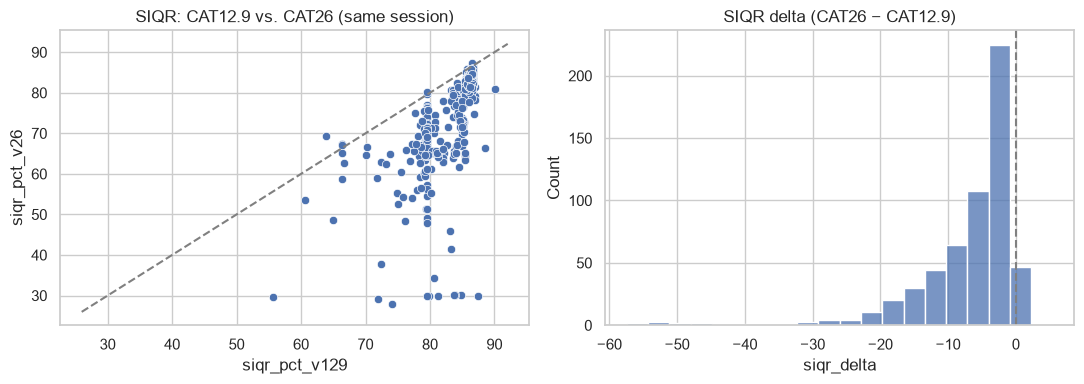

In [9]:
paired = quality[quality["source"] == "cat12"].merge(
    quality[quality["source"] == "cat12_v26"],
    on=["subject_key", "session_id"],
    suffixes=("_v129", "_v26"),
)
print(f"{len(paired)} sessions reprocessed so far")

if len(paired):
    paired["siqr_delta"] = paired["siqr_pct_v26"] - paired["siqr_pct_v129"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.scatterplot(data=paired, x="siqr_pct_v129", y="siqr_pct_v26", ax=axes[0])
    lims = [quality["siqr_pct"].min() - 2, quality["siqr_pct"].max() + 2]
    axes[0].plot(lims, lims, color="grey", linestyle="--")
    axes[0].set_title("SIQR: CAT12.9 vs. CAT26 (same session)")
    sns.histplot(paired["siqr_delta"], bins=20, ax=axes[1])
    axes[1].axvline(0, color="grey", linestyle="--")
    axes[1].set_title("SIQR delta (CAT26 − CAT12.9)")
    plt.tight_layout()
    display(paired[["subject_key", "session_id", "siqr_pct_v129", "siqr_pct_v26", "siqr_delta",
                     "cat_version_v129", "cat_version_v26"]].sort_values("siqr_delta"))


### Region-volume drift (Schaefer GM volumes, paired sessions)

Same idea, but on `features` region rows instead of the QC table — checks
whether the newer CAT version shifts the actual model inputs, not just the
QC score.


In [10]:
with get_session() as s:
    regions = pd.read_sql(
        s.query(Feature)
        .filter(Feature.region != "global", Feature.metric == "vol_gm")
        .statement,
        s.bind,
    )

paired_regions = regions[regions["source"] == "cat12"].merge(
    regions[regions["source"] == "cat12_v26"],
    on=["subject_key", "session_id", "atlas", "region"],
    suffixes=("_v129", "_v26"),
)
if len(paired_regions):
    paired_regions["pct_delta"] = (
        (paired_regions["value_v26"] - paired_regions["value_v129"]) / paired_regions["value_v129"] * 100
    )
    print(f"{len(paired_regions)} region rows compared across "
          f"{paired_regions['session_id'].nunique()} paired sessions")
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(paired_regions["pct_delta"], bins=50, ax=ax)
    ax.axvline(0, color="grey", linestyle="--")
    ax.set_title("Per-region GM volume % delta (CAT26 vs. CAT12.9)")
    ax.set_xlabel("% change")
    plt.tight_layout()
else:
    print("no paired sessions yet")


KeyboardInterrupt: 